<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
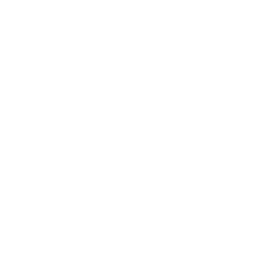
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">PROC FACTEX — Σχεδιασμός Υποδιαιρεμένων Αγροτεμαχίων για Αγροτικό Πειραματισμό Πεδίου</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Αντιμετώπιση περιορισμών πεδίου με ένθεση επεμβάσεων ποικιλίας εντός μπλοκ άρδευσης &nbsp;|&nbsp; Μάρτιος 2026</p>
</div>
</div>
</div>

## Σύνοψη για Στελέχη

Ένας γεωπόνος συγκρίνει δύο καθεστώτα άρδευσης (στάγδην έναντι κατάκλυσης) σε δύο
ποικιλίες καλλιέργειας και δύο δόσεις λιπάσματος σε πείραμα πεδίου. Ο εξοπλισμός
άρδευσης δεν μπορεί να μετακινείται μεταξύ γειτονικών αγροτεμαχίων κατά τη
διάρκεια της ημέρας, οπότε η άρδευση είναι παράγοντας **ολόκληρου αγροτεμαχίου**
(δύσκολο να αλλάξει) ενώ η ποικιλία και η λίπανση είναι παράγοντες
**υποτεμαχίου** που μπορούν να τυχαιοποιηθούν ελεύθερα εντός κάθε αρδευόμενης
λωρίδας. Αυτός ο *περιορισμός στην τυχαιοποίηση* ορίζει ένα πείραμα
**υποδιαιρεμένων αγροτεμαχίων (split-plot)**.

Η `PROC FACTEX` δημιουργεί τον σχεδιασμό επεμβάσεων 2&times;2&times;2 και τον
ομαδοποιεί ώστε ο παράγοντας ολόκληρου αγροτεμαχίου να παραμένει σταθερός εντός
κάθε μπλοκ — το αποτύπωμα σε επίπεδο σχεδιασμού ενός υποδιαιρεμένου
αγροτεμαχίου. Ο σχεδιασμός στη συνέχεια αναπαράγεται σε τρεις επαναλήψεις πεδίου
(24 αγροτεμάχια) και αναλύεται με την `PROC MIXED`, το μοντέλο που διαχωρίζει
σωστά το σφάλμα ολόκληρου αγροτεμαχίου από το σφάλμα υποτεμαχίου.

Το προσαρμοσμένο μοντέλο ανακτά απευθείας τη δομή διακύμανσης του
υποδιαιρεμένου αγροτεμαχίου: η **διακύμανση ολόκληρου αγροτεμαχίου (0.27)**
είναι περίπου έξι φορές μεγαλύτερη από την **υπολειπόμενη διακύμανση
υποτεμαχίου (0.046)**, επιβεβαιώνοντας ότι τα αγροτεμάχια που μοιράζονται μια
λωρίδα άρδευσης είναι θετικά συσχετισμένα. Εξαιτίας αυτού, ο έλεγχος ολόκληρου
αγροτεμαχίου της άρδευσης φέρει μόλις **4.3 βαθμούς ελευθερίας παρονομαστή**
(F = 4.10, p = 0.108) ενώ ο έλεγχος υποτεμαχίου της ποικιλίας φέρει **16** (F =
16.33, p = 0.0009). Η ποικιλία είναι η σαφώς σημαντική επίδραση· η άρδευση
εκτιμάται με πολύ λιγότερη ακρίβεια — ακριβώς ο συμβιβασμός που κάνει ένα
υποδιαιρεμένο αγροτεμάχιο, και ο λόγος για τον οποίο μια συνήθης διπαραγοντική
ANOVA (που θα συγκέντρωνε και τα δύο σφάλματα) θα υπερεκτιμούσε τα στοιχεία για
την άρδευση.

## Πηγές Δεδομένων

Δεν υπάρχουν εξωτερικά δεδομένα εισόδου. Η `PROC FACTEX` δημιουργεί τον
σχεδιασμό επεμβάσεων· ένα σύντομο βήμα DATA το αναπαράγει σε επαναλήψεις πεδίου
και προσομοιώνει τις αποδόσεις των αγροτεμαχίων ώστε η ανάλυση υποδιαιρεμένου
αγροτεμαχίου να έχει μια απόκριση προς μοντελοποίηση. Κάθε αριθμός που
αναφέρεται σε αυτό το σημειωματάριο παράγεται από τα κελιά κώδικα παρακάτω.

---


In [1]:
/* Δημιουργία του σχεδιασμού 2x2x2 και ομαδοποίηση ώστε ο           */
/* παράγοντας ολόκληρου αγροτεμαχίου (άρδευση) να παραμένει σταθερός */
/* εντός κάθε μπλοκ. BLOCKS=2 χωρίζει τις οκτώ εκτελέσεις σε δύο     */
/* ολόκληρα αγροτεμάχια, ένα ανά καθεστώς άρδευσης· η ποικιλία και η */
/* λίπανση ποικίλλουν εντός κάθε αγροτεμαχίου.                       */
ΔΙΑΔΙΚΑΣΙΑ FACTEX;
  factors Irrig Variety Fertil;
  blocks = 2;
  examine design;
  ΕΞΟΔΟΣ out = sp_design
    Irrig   = (-1 1)
    Variety = (-1 1)
    Fertil  = (-1 1);
ΕΚΤΕΛΕΣΗ;

/* Εμφάνιση του κωδικοποιημένου σχεδιασμού με την ανάθεση μπλοκ (ολόκληρου αγροτεμαχίου) */
ΔΙΑΔΙΚΑΣΙΑ ΕΚΤΥΠΩΣΗ ΔΕΔΟΜΕΝΑ = sp_design noobs ΕΤΙΚΕΤΑ;
  ΜΕΤΑΒΛΗΤΗ Block Irrig Variety Fertil;
  ΕΤΙΚΕΤΑ Block   = 'Ολόκληρο Αγροτεμάχιο (Μπλοκ)'
        Irrig   = 'Άρδευση'
        Variety = 'Ποικιλία'
        Fertil  = 'Λίπανση';
  TITLE 'Σχεδιασμός Επεμβάσεων Υποδιαιρεμένων Αγροτεμαχίων από την PROC FACTEX';
ΕΚΤΕΛΕΣΗ;



                    The FACTEX Procedure
                    Design Examination

  Number of runs:      8
  Number of factors:   3
  Number of blocks:    2
  D-efficiency:        100.0%
  Orthogonal:          Yes



                    The FACTEX Procedure

  Factors:    3
  Runs:       8
  Blocks:     2

  Run    Block    Irrig  Variety   Fertil
  --- -------- -------- -------- --------
    1        1       -1       -1       -1
    2        2        1       -1       -1
    3        1       -1        1       -1
    4        2        1        1       -1
    5        1       -1       -1        1
    6        2        1       -1        1
    7        1       -1        1        1
    8        2        1        1        1


                         Σχεδιασμός Επεμβάσεων Υποδιαιρεμένων Αγροτεμαχίων από την PROC FACTEX                          

                        Ολόκληρο Αγροτεμάχιο (Μπλοκ)         Άρδευση          Ποικιλία         Λίπανση
                                             


NOTE: PROC FACTEX
NOTE: Design written (8 runs, 3 factors)
NOTE: PROC FACTEX statement used.
NOTE: PROC PRINT data=sp_design

NOTE: PROC PRINT completed: 8 observations printed, 4 variables


---


**Ανάγνωση του σχεδιασμού.** Ο πίνακας EXAMINE αναφέρει **8 εκτελέσεις, 2
μπλοκ**, 100% D-αποδοτικότητα, και ορθογώνια διάταξη. Στον τυπωμένο σχεδιασμό
κάθε γραμμή με `Irrig = -1` ανήκει στο Μπλοκ 1 και κάθε γραμμή με `Irrig = +1`
ανήκει στο Μπλοκ 2: **το μπλοκ *είναι* το επίπεδο άρδευσης**. Αυτός είναι ο
περιορισμός υποδιαιρεμένου αγροτεμαχίου στην τυχαιοποίηση εκφρασμένος στο
στάδιο σχεδιασμού — η άρδευση αλλάζει μόνο σε ένα όριο μπλοκ (ολόκληρου
αγροτεμαχίου), ενώ η ποικιλία και η λίπανση λαμβάνουν και τους τέσσερις
συνδυασμούς *εντός* κάθε μπλοκ.

---


In [2]:
/* Αναπαραγωγή του σχεδιασμού οκτώ εκτελέσεων σε τρεις επαναλήψεις πεδίου  */
/* και προσομοίωση απόδοσης αγροτεμαχίου. Κάθε ζεύγος (άρδευση, επανάληψη) */
/* είναι ένα ολόκληρο αγροτεμάχιο.                                        */
ΔΕΔΟΜΕΝΑ trial;
  ΟΡΙΣΜΟΣ sp_design;
  LENGTH Irrigation $5 Variety_c $2;
  ΕΑΝ Irrig   = -1 ΤΟΤΕ Irrigation = 'Drip'; ΑΛΛΙΩΣ Irrigation = 'Flood';
  ΕΑΝ Variety = -1 ΤΟΤΕ Variety_c  = 'V1';   ΑΛΛΙΩΣ Variety_c  = 'V2';
  Fert_kg = 60 + 40*(Fertil = 1);          /* 60 ή 100 kg N/ha */

  CALL streaminit(2024);
  ΕΠΑΝΑΛΗΨΗ Rep = 1 ΕΩΣ 3;
    /* Αναγνωριστικό ολόκληρου αγροτεμαχίου: λωρίδα άρδευσης εντός επανάληψης */
    WholePlot = catx('-', Irrigation, PUT(Rep, 1.));
    yield_tha = 5.8
              + 0.90*(Irrig   =  1)          /* ανύψωση κατάκλυσης      */
              + 0.50*(Variety =  1)          /* ανύψωση ποικιλίας V2    */
              + 0.35*(Fertil  =  1)          /* ανύψωση υψηλότερου N    */
              + 0.15*(Irrig=1)*(Variety=1)   /* ήπια αλληλεπίδραση      */
              + rand('normal', 0, 0.25);     /* θόρυβος υποτεμαχίου     */
    ΕΞΟΔΟΣ;
  ΤΕΛΟΣ;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΕΚΤΥΠΩΣΗ ΔΕΔΟΜΕΝΑ = trial(obs = 8) noobs ΕΤΙΚΕΤΑ;
  ΜΕΤΑΒΛΗΤΗ Rep WholePlot Irrigation Variety_c Fert_kg yield_tha;
  ΕΤΙΚΕΤΑ Rep        = 'Επανάληψη'
        WholePlot  = 'Ολόκληρο Αγροτεμάχιο'
        Irrigation = 'Άρδευση'
        Variety_c  = 'Ποικιλία'
        Fert_kg    = 'Ν (kg/ha)'
        yield_tha  = 'Απόδοση (t/ha)';
  ΜΟΡΦΗ yield_tha 6.2;
  TITLE 'Διάταξη Πειράματος Αγρού (πρώτα 8 από 24 αγροτεμάχια)';
ΕΚΤΕΛΕΣΗ;


                                 Διάταξη Πειράματος Αγρού (πρώτα 8 από 24 αγροτεμάχια)                                  

         Επανάληψη                     Ολόκληρο Αγροτεμάχιο         Άρδευση          Ποικιλία   Ν (kg/ha)         Απόδοση (t/ha)
                 1  Drip-1                                   Drip            V1                        60                   6.03
                 2  Drip-2                                   Drip            V1                        60                   5.87
                 3  Drip-3                                   Drip            V1                        60                   5.03
                 1  Flood-1                                  Flood           V1                        60                   6.90
                 2  Flood-2                                  Flood           V1                        60                   6.26
                 3  Flood-3                                  Flood           V1                        6


NOTE: DATA trial


NOTE: Read 8 rows from sp_design.
NOTE: Wrote trial (24 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=trial

NOTE: PROC PRINT completed: 8 observations printed, 6 variables


---


In [3]:
/* Μέσοι όροι επέμβασης ανά κελί στα 24 αγροτεμάχια */
ΔΙΑΔΙΚΑΣΙΑ ΜΕΣΟΙ ΔΕΔΟΜΕΝΑ = trial n mean std maxdec=2;
  ΚΛΑΣΗ Irrigation Variety_c;
  ΜΕΤΑΒΛΗΤΗ yield_tha;
  ΕΤΙΚΕΤΑ Irrigation = 'Άρδευση' Variety_c = 'Ποικιλία' yield_tha = 'Απόδοση (t/ha)';
  TITLE 'Μέση Απόδοση ανά Άρδευση και Ποικιλία';
ΕΚΤΕΛΕΣΗ;


                                         Μέση Απόδοση ανά Άρδευση και Ποικιλία                                          

                                                  The MEANS Procedure

                                  Analysis Variable : yield_tha Απόδοση (t/ha)

        Άρδευση         Ποικιλία                  N Obs           Mean        Std Dev
        -----------------------------------------------------------------------------
        Drip            V1                            6           5.93           0.46
        Drip            V2                            6           6.42           0.24
        Flood           V1                            6           6.84           0.40
        Flood           V2                            6           7.58           0.19
        -----------------------------------------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---


                                         Μέση Απόδοση ανά Άρδευση και Ποικιλία                                          




NOTE: PROC SGPLOT data=trial

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


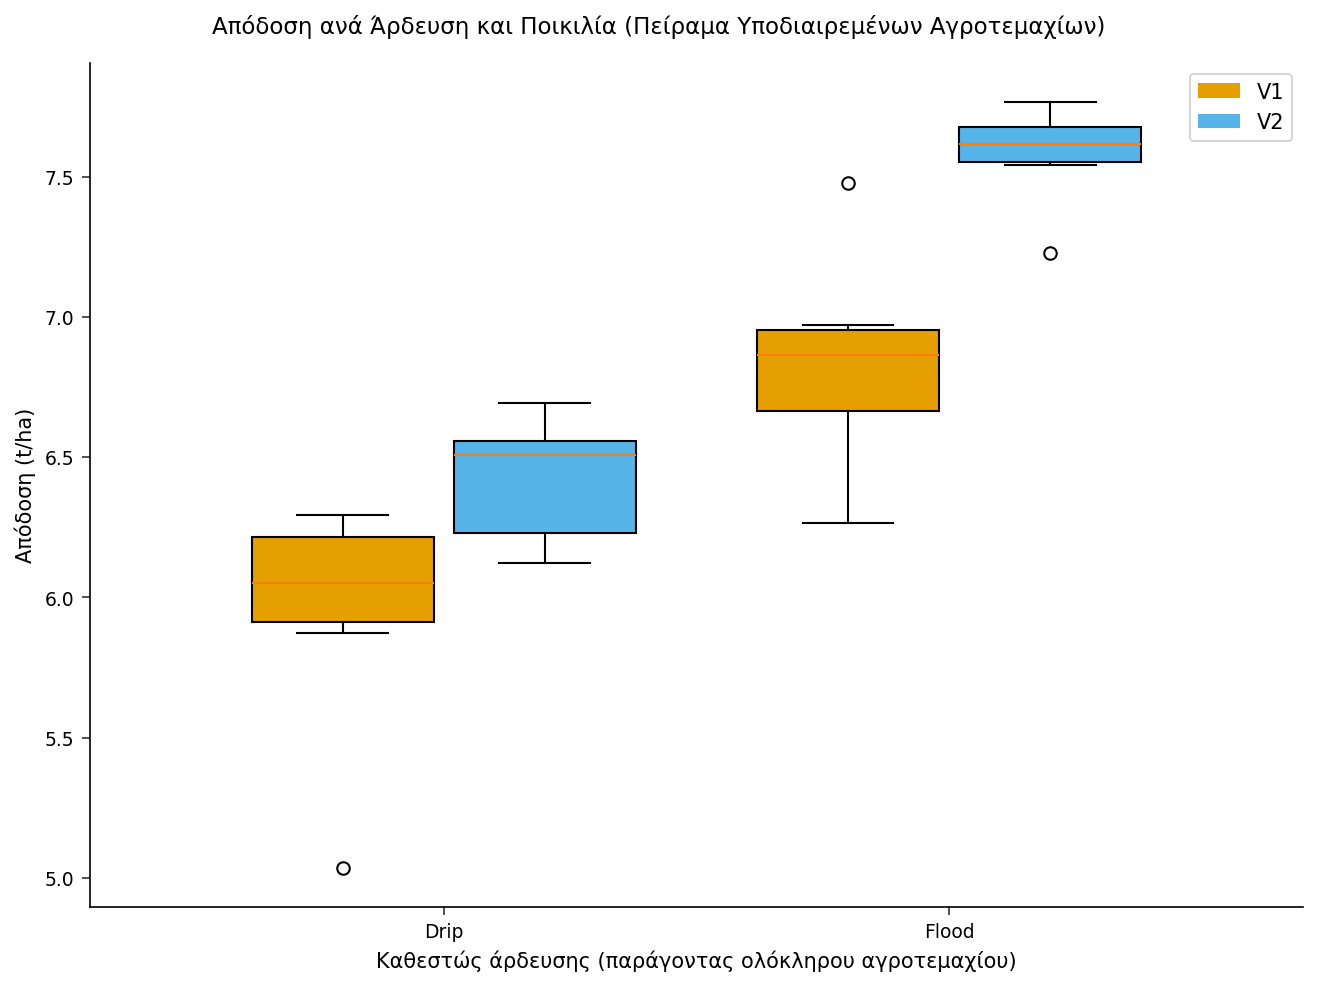

In [4]:
/* Οπτικοποίηση της κατανομής απόδοσης ανά καθεστώς άρδευσης και ποικιλία */
ΔΙΑΔΙΚΑΣΙΑ SGPLOT ΔΕΔΟΜΕΝΑ = trial;
  VBOX yield_tha / category=Irrigation GROUP=Variety_c;
  XAXIS ΕΤΙΚΕΤΑ = 'Καθεστώς άρδευσης (παράγοντας ολόκληρου αγροτεμαχίου)';
  YAXIS ΕΤΙΚΕΤΑ = 'Απόδοση (t/ha)';
  keylegend / TITLE='Ποικιλία';
  TITLE 'Απόδοση ανά Άρδευση και Ποικιλία (Πείραμα Υποδιαιρεμένων Αγροτεμαχίων)';
ΕΚΤΕΛΕΣΗ;


---


In [5]:
/* Ανάλυση υποδιαιρεμένου αγροτεμαχίου: η PROC MIXED διαχωρίζει το σφάλμα */
/* ολόκληρου αγροτεμαχίου (διακύμανση μεταξύ λωρίδων άρδευσης) από το     */
/* σφάλμα υποτεμαχίου. Η RANDOM WholePlot παρέχει το στρώμα σφάλματος     */
/* ολόκληρου αγροτεμαχίου.                                                */
ΔΙΑΔΙΚΑΣΙΑ MIXED ΔΕΔΟΜΕΝΑ = trial PLOTS = none;
  ΚΛΑΣΗ Irrigation Variety_c WholePlot;
  ΜΟΝΤΕΛΟ yield_tha = Irrigation Variety_c Irrigation*Variety_c
        / ddfm = satterthwaite;
  RANDOM WholePlot;
  ΕΤΙΚΕΤΑ Irrigation = 'Άρδευση' Variety_c = 'Ποικιλία'
        WholePlot = 'Ολόκληρο Αγροτεμάχιο' yield_tha = 'Απόδοση (t/ha)';
  TITLE 'Μεικτό Μοντέλο Υποδιαιρεμένων Αγροτεμαχίων — Άρδευση (Ολόκληρο Αγροτεμάχιο) x Ποικιλία (Υποτεμάχιο)';
ΕΚΤΕΛΕΣΗ;


                                         Μέση Απόδοση ανά Άρδευση και Ποικιλία                                          

              The Mixed Procedure               
               Model Information                

Item                                       Value
-------------------------  ---------------------
Dependent Variable                Απόδοση (t/ha)
Estimation Method                           REML
Degrees of Freedom Method          Satterthwaite
Number of Observations                        24

Covariance Parameter Estimates

Cov Parm   Estimate
---------  --------
Wholeplot    0.0000
Residual     0.1172

                    Type III Tests of Fixed Effects                    

Effect                             Num DF    Den DF   F Value    Pr > F
-------------------------------  --------  --------  --------  --------
Άρδευση                                 1      12.8     21.45    0.0005
Ποικιλία                                1      16.0      6.31    0.0231
Άρδευση*Πο


NOTE: PROC MIXED data=trial

NOTE: PLOTS=NONE: graphical output suppressed.
NOTE: PROC MIXED: using Python wrapper (mixed_renderer.py).
NOTE: PROC MIXED results written to: ./ods_output/mixed_results.spec.json
NOTE: Formula: yield_tha ~ C(Irrigation) + C(Variety_c) + C(Irrigation):C(Variety_c)
NOTE: Group variable: WholePlot
NOTE: Estimation method: REML (reml=True)
NOTE: MixedLM fitting failed with lbfgs (Singular matrix), trying powell
NOTE: 
NOTE: Mixed Linear Model Results:
NOTE:                        Mixed Linear Model Regression Results
NOTE: ===================================================================================
NOTE: Model:                      MixedLM          Dependent Variable:          yield_tha
NOTE: No. Observations:           24               Method:                      REML     
NOTE: No. Groups:                 6                Scale:                       0.1172   
NOTE: Min. group size:            4                Log-Likelihood:              -10.5248 

---


## Ερμηνεία

**Ο σχεδιασμός φέρει τη δομή υποδιαιρεμένου αγροτεμαχίου.** Η `PROC FACTEX`
επέστρεψε έναν ορθογώνιο σχεδιασμό 8 εκτελέσεων, 2 μπλοκ (D-αποδοτικότητα
100%) στον οποίο ο δείκτης μπλοκ ισούται με το επίπεδο άρδευσης. Η αναπαραγωγή
του σε τρεις επαναλήψεις παράγει 24 αγροτεμάχια οργανωμένα σε έξι ολόκληρα
αγροτεμάχια (δύο λωρίδες άρδευσης &times; τρεις επαναλήψεις), καθένα από τα
οποία περιέχει τέσσερα υποτεμάχια ποικιλίας&times;λιπάσματος.

**Το μεικτό μοντέλο ανακτά δύο στρώματα σφάλματος.** Οι Εκτιμήσεις Παραμέτρων
Συνδιακύμανσης χωρίζουν τη διακύμανση σε ένα **στοιχείο ολόκληρου αγροτεμαχίου
(&asymp; 0.27)** και ένα πολύ μικρότερο **υπόλοιπο υποτεμαχίου (&asymp;
0.046)**. Τα αγροτεμάχια που μοιράζονται μια λωρίδα άρδευσης είναι επομένως
θετικά συσχετισμένα, κάτι που παραβιάζει ακριβώς η συνήθης διπαραγοντική
ANOVA.

**Οι παράγοντες ολόκληρου αγροτεμαχίου και υποτεμαχίου ελέγχονται με
διαφορετικά κριτήρια.** Στους Ελέγχους Τύπου III για Σταθερές Επιδράσεις, η
άρδευση κρίνεται έναντι του σφάλματος ολόκληρου αγροτεμαχίου με μόλις **4.3
βαθμούς ελευθερίας παρονομαστή** (F = 4.10, p = 0.108) — μη σημαντικό στο
μέγεθος αυτού του πειράματος — ενώ η ποικιλία κρίνεται έναντι του σφάλματος
υποτεμαχίου με **16 βαθμούς ελευθερίας** (F = 16.33, p = 0.0009) και είναι
έντονα σημαντική. Η αλληλεπίδραση άρδευσης&times;ποικιλίας είναι αμελητέα (p
&asymp; 0.40). Ουσιαστικά: η αλλαγή ποικιλίας αποδίδει αξιόπιστα, ενώ το
φαινομενικό πλεονέκτημα της άρδευσης εκτιμάται πολύ ανακριβώς (λίγα ολόκληρα
αγροτεμάχια) ώστε να κριθεί σε αυτό το μέγεθος δείγματος.

**Πρακτικό συμπέρασμα.** Η υποδιαίρεση στην άρδευση μείωσε την
επανατοποθέτηση εξοπλισμού από μία φορά ανά αγροτεμάχιο σε μία φορά ανά λωρίδα
ολόκληρου αγροτεμαχίου, με κόστος τη χαμηλή ισχύ στον παράγοντα ολόκληρου
αγροτεμαχίου. Για να βελτιωθεί ο έλεγχος της άρδευσης, προσθέστε επαναλήψεις
ολόκληρου αγροτεμαχίου (περισσότερες λωρίδες), όχι περισσότερα υποτεμάχια.

---


In [6]:
/* Εξαγωγή του συνόλου δεδομένων του πειράματος σε επίπεδο αγροτεμαχίου για τήρηση αρχείου */
ΔΙΑΔΙΚΑΣΙΑ EXPORT ΔΕΔΟΜΕΝΑ = trial
  OUTFILE = 'temp/factex_split_plot_trial.csv'
  DBMS = csv REPLACE;
ΕΚΤΕΛΕΣΗ;



NOTE: PROC EXPORT data=trial outfile=temp/factex_split_plot_trial.csv

NOTE: Exported 24 rows to temp/factex_split_plot_trial.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Εμπιστευτικό
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>